### Heat Equation

#### Imports

In [623]:
# Start Cell
# Adjust import path
%matplotlib inline
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML
import random

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1

In [624]:
# Start Cell
### Setup
training_span = (0, 1)
num_samples = 15
noiselevel = .05
num_regression_points = 15
numPODmodes = 5

normalization = 1e-5
ndraws = 600

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=normalization,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
sampler = step1.TrajectorySampler(
    training_span,
    num_samples,
    noiselevel,
    num_regression_points,
    synced=False,
)
(
    true_states,
    time_domain_sampled,
    snapshots_sampled,
    training_inputs,
) = sampler.multisample(config.input_parameters, plot=False)



EXPERIMENTAL SCENARIO
Data:
	* 5 trajectories
	* 15 randomly sampled snapshots in each trajectory
	* 5.00% noise
	* training   0.00 ≤ t < 1.00
	* prediction 0.00 ≤ t ≤ 2.00
Dimension: retaining 5 POD modes
Training: using 15 regression points
GP regularization: eta = 1.00e-05
Posterior: 600 draws



In [625]:
# Start Cell
true_states, time_domain_sampled, snapshots_sampled, training_inputs = np.array(true_states), np.array(time_domain_sampled), np.array(snapshots_sampled), np.array(training_inputs)
true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape, training_inputs.shape

((5, 500, 500), (5, 15), (5, 500, 15), (5, 2, 15))

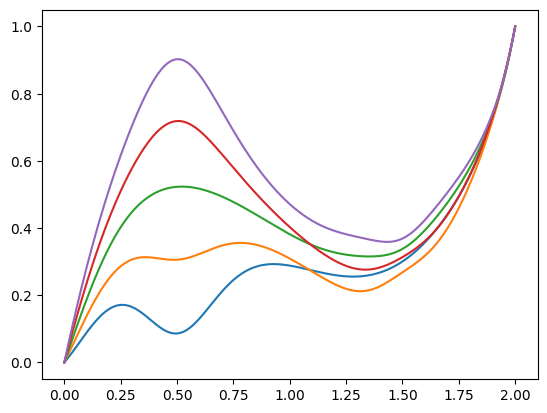

In [626]:
# Start Cell
# Plot the truestates
time_domain = config.time_domain
fig, ax = plt.subplots() 
lines = plt.plot(time_domain, true_states[:,:,0].T)

def update(frame):
    for idx, line in enumerate(lines):
        lines[idx].set_data(time_domain, true_states[idx, :, frame].T)
    return lines

ani = FuncAnimation(
    fig=fig,
    func=update,
    frames=100,
    interval=50,    # delay between frames in milliseconds
    blit=True       # only redraw the bits that change (faster)
)

HTML(ani.to_jshtml())   # or .to_html5_video()
plt.show()

#### Fit Basis

reducing noisy training states to 5 dimensions...done in 0.04 s.
(5, 5, 15) (5, 15)


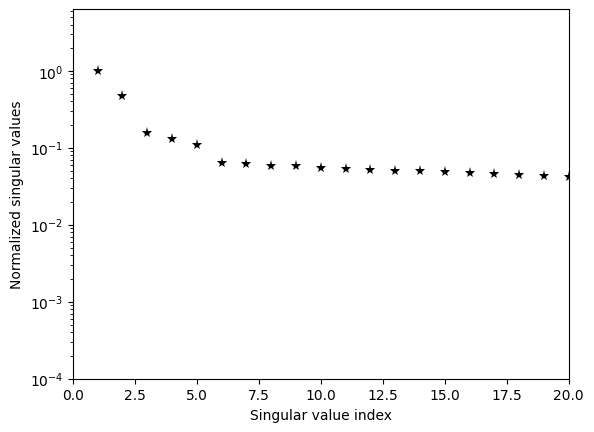

In [627]:
# Start Cell
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(np.hstack(snapshots_sampled))
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    # utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = [basis.compress(Q) for Q in snapshots_sampled]
    true_states_compressed = [basis.compress(Q) for Q in true_states]

snapshots_compressed = np.array(snapshots_compressed)
true_states_compressed = np.array(true_states_compressed)
print(snapshots_compressed.shape, time_domain_sampled.shape)

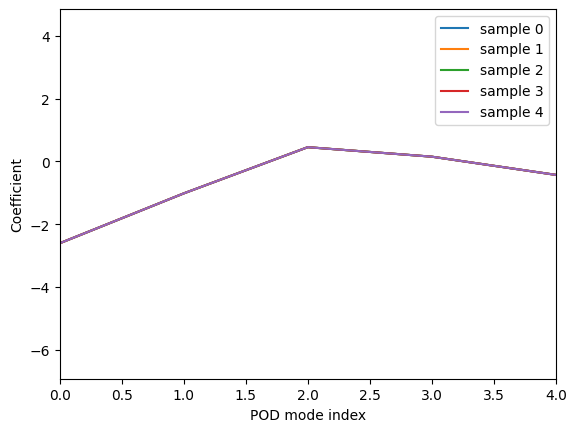

In [628]:
# Start Cell
n_modes = snapshots_compressed.shape[1]
mode_idx = np.arange(n_modes)

fig, ax = plt.subplots()
ax.set_xlim(0, n_modes - 1)
ax.set_ylim(snapshots_compressed.min(), snapshots_compressed.max())

lines = []
for i in range(snapshots_compressed.shape[0]):
    # at frame=0, plot coef vs. mode-index
    line, = ax.plot(
        mode_idx,
        snapshots_compressed[i, :, 0],
        label=f"sample {i}"
    )
    lines.append(line)
ax.set_xlabel("POD mode index")
ax.set_ylabel("Coefficient")
ax.legend()

def update(frame):
    for idx, line in enumerate(lines):
        y = snapshots_compressed[idx, :, frame]
        line.set_data(mode_idx, y)
    return lines

ani = FuncAnimation(
    fig, update,
    frames=snapshots_compressed.shape[2],  # = n_times
    interval=50,
    blit=True
)
plt.show()

#### Probabilistic Layer

##### Fit the gps

Starting SVI optimization...
Iteration 0: loss = 3758.8479
Iteration 100: loss = 1964.5627
Iteration 200: loss = 1305.8938
Iteration 300: loss = 1030.9889
Iteration 400: loss = 968.4366
Iteration 500: loss = 863.1240
Iteration 600: loss = 769.5226
Iteration 700: loss = 579.2902
Iteration 800: loss = 560.3444
Iteration 900: loss = 464.2939
Iteration 1000: loss = 442.0042
Iteration 1100: loss = 288.7273
Iteration 1200: loss = 316.2136
Iteration 1300: loss = 276.0750
Iteration 1400: loss = 286.5733
Iteration 1500: loss = 159.1831
Iteration 1600: loss = 191.2412
Iteration 1700: loss = 103.4269
Iteration 1800: loss = 111.8001
Iteration 1900: loss = 89.8899
Iteration 2000: loss = 78.7003
Iteration 2100: loss = 84.3857
Iteration 2200: loss = 44.3829
Iteration 2300: loss = 35.7467
Iteration 2400: loss = -4.5789
Iteration 2500: loss = 2.7882
Iteration 2600: loss = -10.8473
Iteration 2700: loss = -22.0126
Iteration 2800: loss = -24.4442
Iteration 2900: loss = 24.5513
Iteration 3000: loss = 25.81

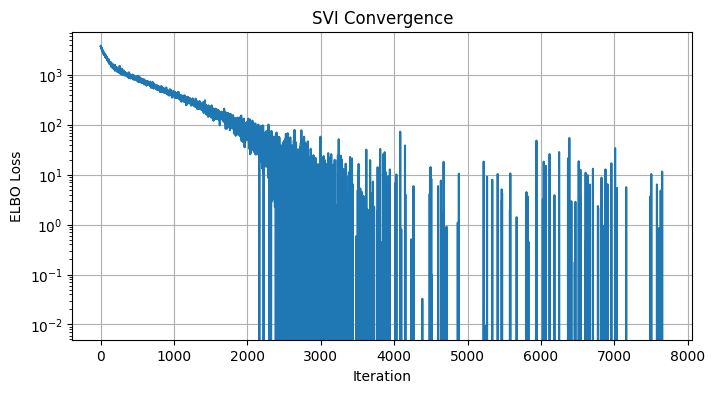

In [654]:
# Start Cell
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from things.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[1]
    
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        # Get time scale
        time_range = time[i].max() - time[i].min()
        place_holder_ls = []
        place_holder_vars = []
        place_holder_noises = []
        for j in range(snapshots_compressed.shape[1]): 
            # For oscillatory data, we need small lengthscales
            # Start with a prior centered at ~1/20th of the time range
            # lengthscale = numpyro.sample(f"lengthscale{i}{j}", 
            #                             dist.LogNormal(jnp.log(time_range/20), 1.0))
            lengthscale = numpyro.sample(f"lengthscale{i}{j}", 
                                        dist.LogNormal(jnp.log(time_range/1e1), 1.0))
            place_holder_ls.append(lengthscale)
            
            # Variance based on data variance
            variance = numpyro.sample(f"variance{i}{j}", 
                                    dist.LogNormal(jnp.log(data_std**2), 0.5))
            place_holder_vars.append(variance)
            
            # Small noise since data looks clean
            noise = numpyro.sample(f"noise{i}{j}", 
                                dist.LogNormal(-8.0, 1.0))  # Very small noise
            place_holder_noises.append(noise)
            
            # Compute kernel matrix
            K = kernel(time[i].reshape(-1,1), time[i].reshape(-1,1), lengthscale, variance)
            
            # Add tiny regularization for numerical stability
            K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
            
            # GP prior
            x = numpyro.sample(f"f{i}{j}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
            
            # Likelihood
            with numpyro.plate(f"data{i}{j}", num_time_steps):
                numpyro.sample(f"y{i}{j}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i][j])
        Ls.append(place_holder_ls)
        Vars.append(place_holder_vars)
        noises.append(place_holder_noises)

# Create autoguide
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=30)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled, 
                                  qhat=snapshots_compressed,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
samples = predictive(rng_key,
                     time=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

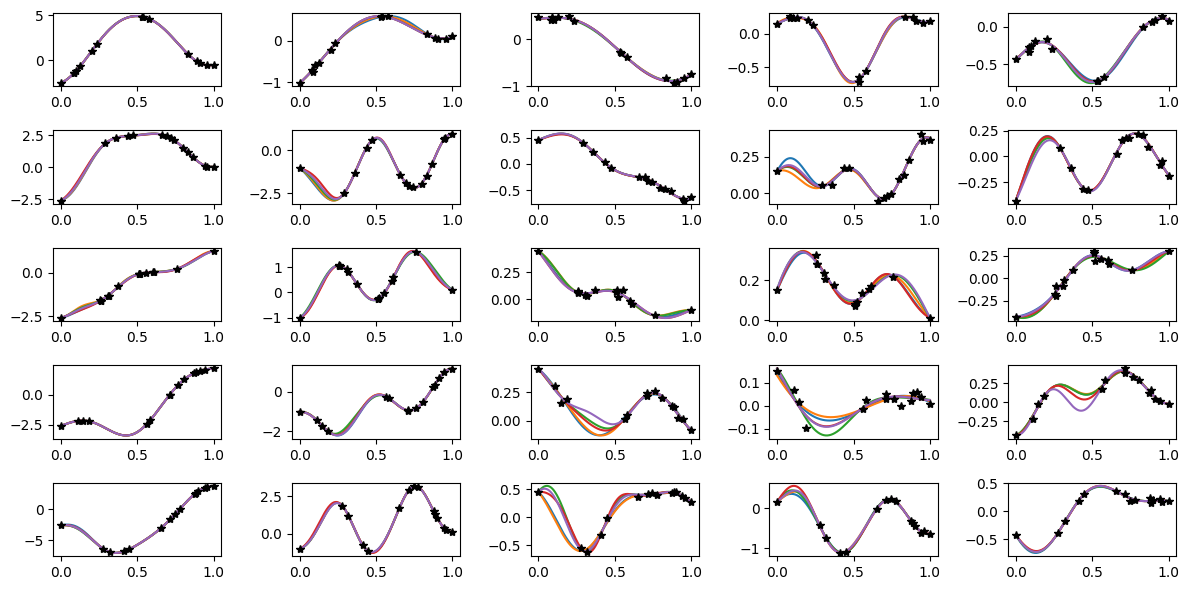

In [655]:
# Start Cell
### Plot gp predictions
from things.bgp_jax import BayesianGP

fig, ax = plt.subplots(numPODmodes, 5, figsize = (12,6))

num_pulls = 5
x_test = jnp.linspace(0,1,250)

for i in range(num_pulls):
    rand_idx = random.randint(0, len(samples['lengthscale00']))

    gp = BayesianGP()
    for j in range(numPODmodes):
        gp.X_train = time_domain_sampled[j,][:,None]
        for k in range(snapshots_compressed.shape[1]):
            Ls = np.array([samples[f'lengthscale{j}{k}'][rand_idx] for i in range(numPODmodes)])
            Vs = np.array([samples[f'variance{j}{k}'][rand_idx] for i in range(numPODmodes)])
            Ns = np.array([samples[f'noise{j}{k}'][rand_idx] for i in range(numPODmodes)])
            gp.y_train = snapshots_compressed[j][k]
            mean, std, _ = gp.predict_with_hypers(X_test=x_test[:,None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
            ax[j][k].plot(x_test, mean)

for i in range(numPODmodes):
    for j in range(snapshots_compressed.shape[1]):
        ax[i][j].plot(time_domain_sampled[i], snapshots_compressed[i][j], 'k*')

fig.tight_layout()

In [656]:
# Start Cell
### Compute mean and std of each thing that we need

Ls_means, Ls_stds, Vs_means, Vs_stds, Ns_means, Ns_stds, Fs_means = [],[],[],[],[],[],[]
for i in range(numPODmodes):
    Ls_means.append(np.array([samples[f'lengthscale{i}{j}'].mean() for j in range(snapshots_compressed.shape[1])]))
    Ls_stds.append(np.array([samples[f'lengthscale{i}{j}'].std() for j in range(snapshots_compressed.shape[1])]))
    Vs_means.append(np.array([samples[f'variance{i}{j}'].mean() for j in range(snapshots_compressed.shape[1])]))
    Vs_stds.append(np.array([samples[f'variance{i}{j}'].std() for j in range(snapshots_compressed.shape[1])]))
    Ns_means.append(np.array([samples[f'noise{i}{j}'].mean() for j in range(snapshots_compressed.shape[1])]))
    Ns_stds.append(np.array([samples[f'noise{i}{j}'].std() for j in range(snapshots_compressed.shape[1])]))
    Fs_means.append(np.array([samples[f'f{i}{j}'].mean(axis=0) for j in range(snapshots_compressed.shape[1])]))

Ls_means = np.stack(Ls_means)   # → (numPODmodes, n_snapshots)
Ls_stds  = np.stack(Ls_stds)
Vs_means = np.stack(Vs_means)
Vs_stds  = np.stack(Vs_stds)
Ns_means = np.stack(Ns_means)
Ns_stds  = np.stack(Ns_stds)
Fs_means = np.stack(Fs_means) 
Ls_means.shape, Ls_stds.shape, Vs_means.shape, Vs_stds.shape, Ns_means.shape, Ns_stds.shape, Fs_means.shape

((5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5, 15))

In [657]:
# Now let's check the derivative predictions
from things.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

mu_z_modes = []
for i in range(numPODmodes):
    mu_zs = []
    for j in range(snapshots_compressed.shape[1]):
        lengthscale = Ls_means[i][j]
        variance = Vs_means[i][j]
        Xi = Fs_means[i][j]
        # Cache inverse computation
        Kyy = get_c_phi(lengthscale, variance, time_domain_sampled[i].reshape(-1,1), normalization)
        Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(time_domain_sampled.shape[1]))
        Ds = get_dash_c_phi(lengthscale, variance, time_domain_sampled[i].reshape(-1,1)) @ Kyy_inv
        mu_z_j  = Ds @ Xi             # (num_time_steps,)
        mu_zs.append(mu_z_j)

    mu_z_modes.append(jnp.array(mu_zs))

mu_z_all = jnp.array(mu_z_modes)               # (numPODmodes, num_time_steps)
mu_z_all.shape

(5, 5, 15)

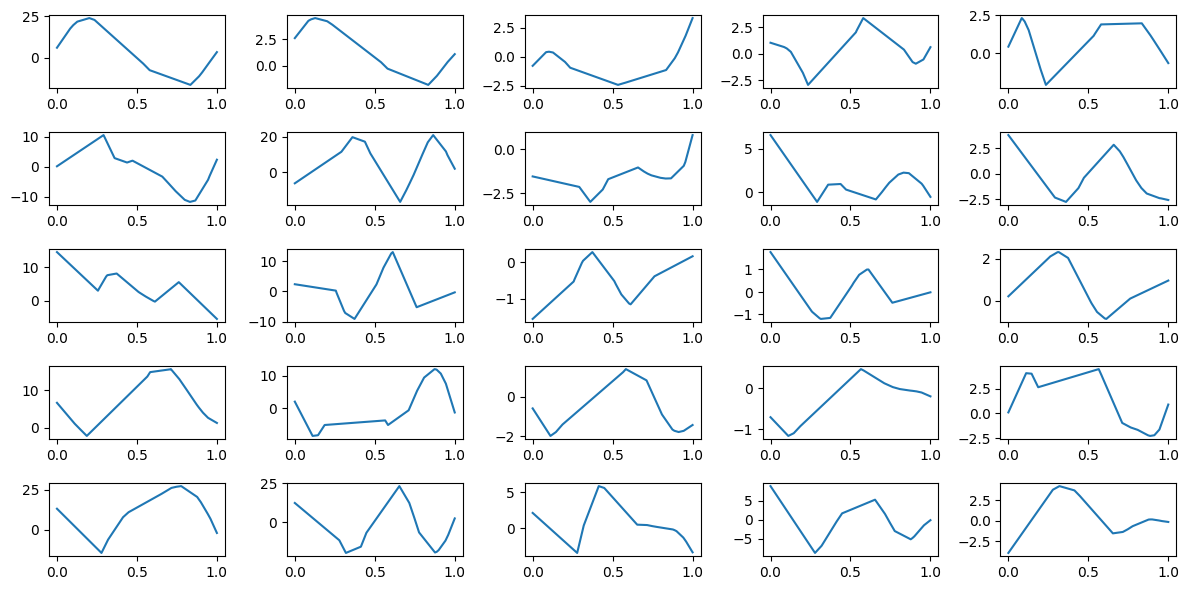

In [658]:
fig, ax = plt.subplots(numPODmodes, snapshots_compressed.shape[1], figsize=(12,6))
for i in range(numPODmodes):
    for j in range(snapshots_compressed.shape[1]):
        ax[i][j].plot(time_domain_sampled[i], mu_z_all[i][j])

fig.tight_layout()
plt.show()

#### Latent State Layer

Starting SVI optimization...
Iteration 0: loss = 10608778.0000
Iteration 100: loss = 1352335.6250
Iteration 200: loss = 312482.6250
Iteration 300: loss = 166450.1094
Iteration 400: loss = 126788.5703
Iteration 500: loss = 100667.9609
Iteration 600: loss = 85070.1641
Iteration 700: loss = 70447.0469
Iteration 800: loss = 61333.9805
Iteration 900: loss = 55081.7383
Iteration 1000: loss = 47504.3750
Iteration 1100: loss = 42806.4375
Iteration 1200: loss = 35351.0312
Iteration 1300: loss = 34452.1250
Iteration 1400: loss = 28752.4121
Iteration 1500: loss = 26189.8320
Iteration 1600: loss = 22398.1914
Iteration 1700: loss = 21347.9922
Iteration 1800: loss = 18870.0176
Iteration 1900: loss = 16710.0098
Iteration 2000: loss = 15335.4287
Iteration 2100: loss = 13387.7100
Iteration 2200: loss = 11026.6416
Iteration 2300: loss = 10363.0752
Iteration 2400: loss = 9582.8955
Iteration 2500: loss = 8274.8779
Iteration 2600: loss = 6522.5913
Iteration 2700: loss = 6306.6562
Iteration 2800: loss = 508

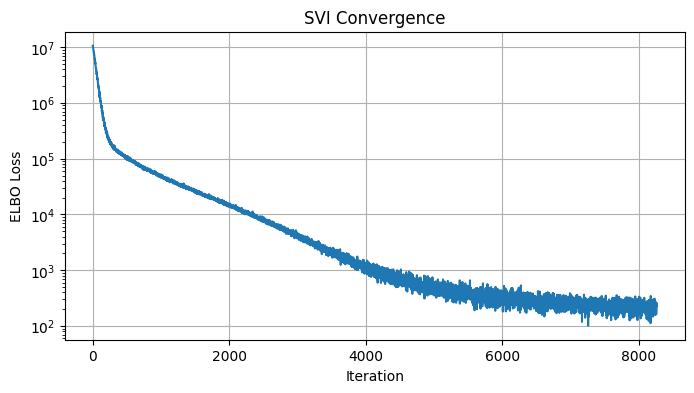

In [659]:
# Start Cell
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from things.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()

def model(time_domain, qhat, chi, normalization=1e-6):
    num_time_steps = time_domain.shape[1]

    for i in range(numPODmodes):
        time = time_domain[i]
        for j in range(snapshots_compressed.shape[1]):
            # fixed hyperparameters
            lengthscale = Ls_means[i][j]
            variance    = Vs_means[i][j]

            norm = normalization
            for _ in range(5):
                Kyy = get_c_phi(lengthscale, variance, time, norm)
                try:
                    L = jnp.linalg.cholesky(Kyy)   # <-- capture the factor
                    break
                except jnp.linalg.LinAlgError:
                    norm *= 10.
            else:
                raise RuntimeError(f"Mode {i}: could not find a PSD covariance after 5 tries")

            # 2) sample using the scale_tril argument (no re-validation of covariance_matrix)
            Xi = numpyro.sample(
                f"Xi{i}{j}",
                dist.MultivariateNormal(
                    loc=jnp.zeros(num_time_steps),
                    scale_tril=L           # <-- use the L directly
                )
            )
            numpyro.sample(f"Yi{i}{j}",
                        dist.Normal(Xi, chi),
                        obs=qhat[i][j])
            

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoNormal(model)

# Setup optimizer
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time_domain=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time_domain=time_domain_sampled, 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization = normalization
                                  )
    return svi_state, loss

# Training loop
num_iterations = 20000  # Adjust as needed
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=100)
samples = predictive(rng_key,
                     time_domain=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [660]:
# Start Cell
Xs_means, Xs_stds = [], []

for i in range(numPODmodes):
    Xs_means.append(np.array([samples[f'Xi{i}{j}'].mean(axis=0) for j in range(snapshots_compressed.shape[1])]))
    Xs_stds.append(np.array([samples[f'Xi{i}{j}'].std(axis=0) for j in range(snapshots_compressed.shape[1])]))

Xs_means = np.stack(Xs_means, axis=0)
Xs_stds = np.stack(Xs_stds, axis=0)

Xs_means.shape, Xs_stds.shape

((5, 5, 15), (5, 5, 15))

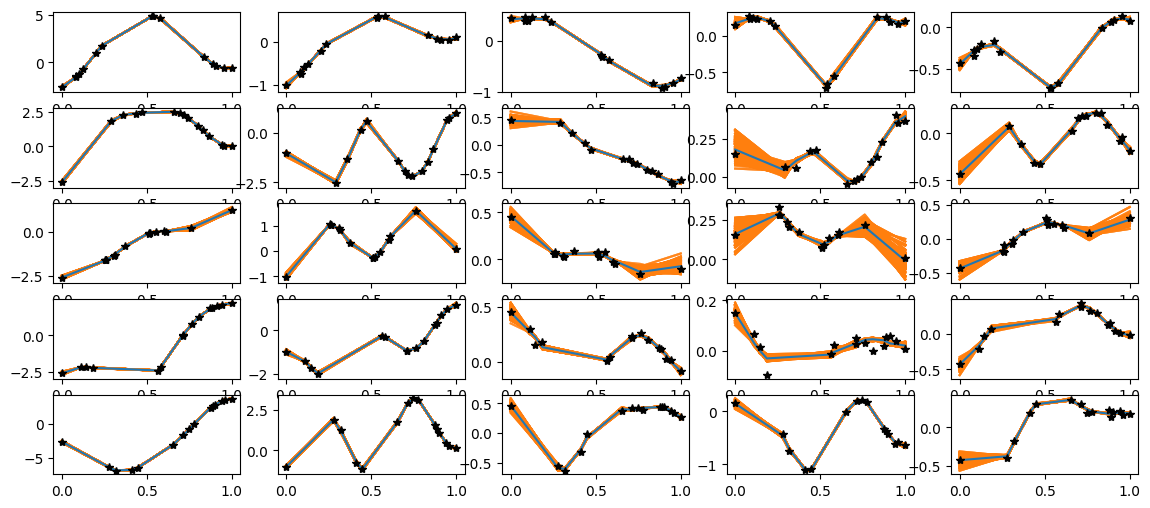

In [661]:
Xss = []
for i in range(ndraws):
    rand_idx = random.randint(0, len(samples['Xi00']))
    Xs = []
    for j in range(numPODmodes):
        xs = []
        for k in range(snapshots_compressed.shape[1]):
            X = samples[f'Xi{j}{k}'][rand_idx]
            xs.append(X)
        Xs.append(xs)
    Xss.append(Xs)

Xss = np.array(Xss)

fig, ax = plt.subplots(numPODmodes, snapshots_compressed.shape[1], figsize=(14,6))
for i in range(numPODmodes):
    for j in range(snapshots_compressed.shape[1]):
        ax[i][j].plot(time_domain_sampled[i], Xss[:,i,j,:].T, 'tab:orange', alpha=.5)
        ax[i,j].plot(time_domain_sampled[i], Xs_means[i][j], 'tab:blue')
        ax[i][j].plot(time_domain_sampled[i], snapshots_compressed[i][j], 'k*')
plt.show()

##### Gradient Matching Layer

(5, 15)
(5, 15)
(5, 15)
Starting SVI optimization...
(5, 15)
Iteration 0: loss = 3712983.2500
Iteration 100: loss = 786753.5000
Iteration 200: loss = 421778.2500
Iteration 300: loss = 320893.5625
Iteration 400: loss = 223858.8750
Iteration 500: loss = 275568.7812
Iteration 600: loss = 197066.4688
Iteration 700: loss = 211086.2500
Iteration 800: loss = 176652.2656
Iteration 900: loss = 168931.1562
Iteration 1000: loss = 160045.9531
Iteration 1100: loss = 162213.7031
Iteration 1200: loss = 156697.0000
Iteration 1300: loss = 153555.9531
Iteration 1400: loss = 152596.2969
Iteration 1500: loss = 152846.9375
Iteration 1600: loss = 151864.4375
Iteration 1700: loss = 153325.9375
Iteration 1800: loss = 150598.0156
Iteration 1900: loss = 154135.5781
Iteration 2000: loss = 150665.1094
Iteration 2100: loss = 150896.5625
Iteration 2200: loss = 153223.2969
Iteration 2300: loss = 151348.0938
Iteration 2400: loss = 150618.8125
Iteration 2500: loss = 150999.5469
Iteration 2600: loss = 150481.0781
Itera

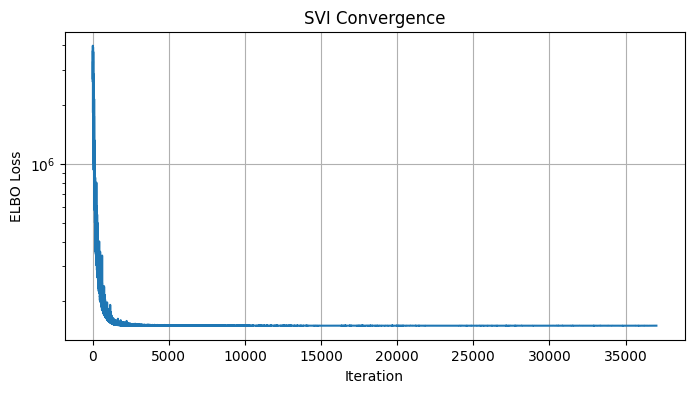

In [662]:
# Start Cell
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from things.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()
rom = config.ReducedOrderModel()

ddt = opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled[0])
_states, ddts, _ = ddt.estimate(states=snapshots_compressed[0,:,:], inputs=training_inputs[0])
rom.fit(snapshots_compressed[0,:,:], ddts = ddts, inputs=training_inputs[0])

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

def model(time_domain, qhat, O_mean, normalization=1e-6, custom_scales = None):
    print(time_domain.shape)
    num_time_steps = time_domain.shape[1]

    # Col Number and corresponding operator
    # 0 - Constant, Linear 1-5, Quad 6-20, Input 21-22, StateInput 23-32
    if custom_scales == None:
        O = numpyro.sample('O',
                        dist.Normal(jnp.zeros_like(O_mean), 10))
    else:
        O = numpyro.sample('O',
                        dist.Normal(jnp.zeros_like(O_mean), custom_scales))

    Kyys = []
    
    for i in range(numPODmodes):
        time = time_domain[i].reshape(-1)
        kyys = []
        for j in range(qhat.shape[1]):
            # Priors for hyperparameters
            lengthscale = Ls_means[i][j]
            variance = Vs_means[i][j]

            Kyy = get_c_phi(lengthscale, variance, time, normalization)
            kyys.append(Kyy)
        
        Kyys.append(jnp.array(kyys))
        
    f_Xi_ohats = []
    for j in range(numPODmodes):
        f_Xi_ohats.append(rom._assemble_data_matrix(Xs_means[j], inputs=training_inputs[j]) @ O.T)
    
    f_Xi_ohat = jnp.array(f_Xi_ohats)
    
    for i in range(numPODmodes):
        time = time_domain[i]
        for j in range(qhat.shape[1]):
            lengthscale = Ls_means[i][j]
            variance = Vs_means[i][j]
            Kyy = Kyys[i][j]
            Xi = Xs_means[i][j]
            
            # Cache inverse computation
            # Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))
            Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
            Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
            CDashs = get_c_phi_dash(lengthscale, variance, time)
            DashCs = get_dash_c_phi(lengthscale, variance, time)
            CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
            CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
            # Use Cholesky decomposition for more stable inverse
            CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
            A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
            mu_zi = Ds @ Xi
            gamma = 1e-2
            constraint_cov = A + gamma * jnp.eye(num_time_steps)
            
            numpyro.sample(
                f'ode_constraint{i}{j}',
                dist.MultivariateNormal(mu_zi, constraint_cov),
                obs=f_Xi_ohat[i, :, j]
                )

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=500)

# Setup optimizer
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Create some custom scales
scales_1d = [5e-1] + [5e-2]*5 + [1e-2]*15 + [5e1]*2 + [5e-2]*10  # len == 33
custom_scales = jnp.array(scales_1d)[None, :].repeat(5, axis=0)  # -> (5,33)

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time_domain=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     O_mean=np.zeros(shape=(5,33)),
                     normalization=normalization,
                     custom_scales=custom_scales
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time_domain=time_domain_sampled, 
                                  qhat=snapshots_compressed,
                                  O_mean=np.zeros(shape = (5,33)),
                                  normalization=normalization,
                                  custom_scales=custom_scales
                                  )
    return svi_state, loss

# Training loop
num_iterations = 100000  # Adjust as needed
losses = []
patience = 5000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
samples = predictive(rng_key,
                     time_domain=time_domain_sampled, 
                     qhat=snapshots_compressed,
                     O_mean=np.zeros(shape = (5,33)),
                     normalization=normalization,
                     custom_scales=custom_scales
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Results Analysis

In [663]:
place_holder_O = np.load('70_.12_gpbayes.npy')

##### Image Comparison Of Operators

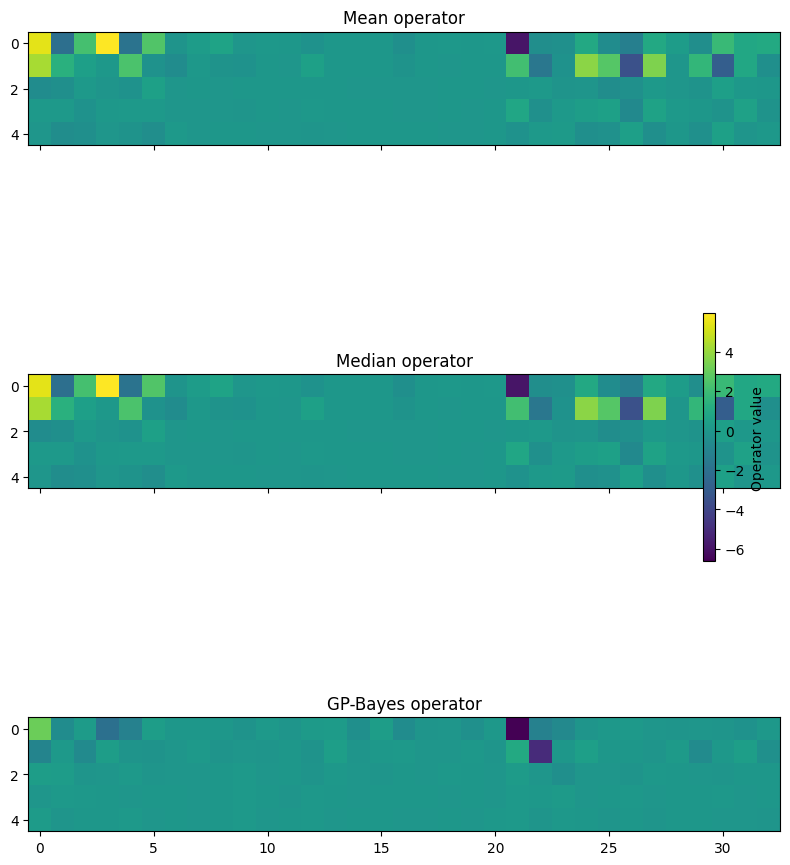

In [664]:
import numpy as np
import matplotlib.pyplot as plt

mean_O      = samples['O'].mean(0)
median_O    = np.median(samples['O'], axis=0)
gp_bayes_O  = place_holder_O

vmin = min(mean_O.min(),    median_O.min(),    gp_bayes_O.min())
vmax = max(mean_O.max(),    median_O.max(),    gp_bayes_O.max())

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True, sharey=True)

im0 = axes[0].imshow(mean_O,   vmin=vmin, vmax=vmax)
axes[0].set_title("Mean operator")
im1 = axes[1].imshow(median_O, vmin=vmin, vmax=vmax)
axes[1].set_title("Median operator")
im2 = axes[2].imshow(gp_bayes_O, vmin=vmin, vmax=vmax)
axes[2].set_title("GP-Bayes operator")

cbar = fig.colorbar(im2, ax=axes, orientation="vertical", fraction=0.02, pad=0.04)
cbar.set_label("Operator value")
fig.tight_layout()
plt.show()

##### Trajectory Comparison Within Training Domain

In [665]:
eval_time = np.linspace(0, 1, 250)

import random
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

num_pod_modes = snapshots_compressed.shape[0]
pred_samples = []
op_trajs = []

for j in range(ndraws):
    trajs = []
    for i in range(num_pod_modes):
        # keep drawing until the solver produces exactly len(eval_time) time‐points
        num_retrys = 0
        while True:
            num_retrys += 1
            if num_retrys == 1000:
                raise RuntimeError
            idx = random.randint(0, len(samples['O']) - 1)
            O_sample = samples['O'][idx]

            # re‐load the operator into your ROM
            rom._extract_operators(np.array(O_sample))

            # predict gives you `predict_result_.t` and `.y`
            rom.predict(
                state0=snapshots_compressed[i, :, 0],
                t=eval_time,
                input_func=config.input_func_factory(config.input_parameters[i])
            )
            sol = rom.predict_result_

            if sol.t.shape[0] != eval_time.shape[0]:
                print(f"Mode {i}: got {sol.t.shape[0]} time‐steps, expected {eval_time.shape[0]}. Retrying…")
                continue

            # success: store the trajectory (shape: [state_dim, len(eval_time)]) and break out
            trajs.append(sol.y)
            rom._extract_operators(place_holder_O)
            rom.predict(
                state0=snapshots_compressed[i, :, 0],
                t=eval_time,
                input_func=config.input_func_factory(config.input_parameters[i])
            )
            sol = rom.predict_result_
            op_trajs.append(sol.y)
            break

    pred_samples.append(trajs)

pred_samples = np.array(pred_samples)
op_trajs = np.array(op_trajs)


Mode 4: got 140 time‐steps, expected 250. Retrying…
Mode 4: got 142 time‐steps, expected 250. Retrying…
Mode 4: got 138 time‐steps, expected 250. Retrying…
Mode 4: got 143 time‐steps, expected 250. Retrying…
Mode 4: got 135 time‐steps, expected 250. Retrying…
Mode 4: got 141 time‐steps, expected 250. Retrying…
Mode 4: got 137 time‐steps, expected 250. Retrying…
Mode 4: got 137 time‐steps, expected 250. Retrying…
Mode 4: got 135 time‐steps, expected 250. Retrying…
Mode 4: got 142 time‐steps, expected 250. Retrying…
Mode 4: got 144 time‐steps, expected 250. Retrying…
Mode 4: got 136 time‐steps, expected 250. Retrying…
Mode 4: got 138 time‐steps, expected 250. Retrying…
Mode 4: got 142 time‐steps, expected 250. Retrying…
Mode 4: got 142 time‐steps, expected 250. Retrying…
Mode 4: got 138 time‐steps, expected 250. Retrying…
Mode 4: got 136 time‐steps, expected 250. Retrying…
Mode 4: got 138 time‐steps, expected 250. Retrying…
Mode 4: got 144 time‐steps, expected 250. Retrying…
Mode 4: got 

RuntimeError: 

In [ ]:
mean_sample = pred_samples.mean(axis=0)
median_sample = np.median(pred_samples, axis=0)
q5 = np.quantile(pred_samples, .01, axis=0)
q95 = np.quantile(pred_samples, .99, axis=0)

pred_samples.shape, op_trajs.shape, mean_sample.shape, median_sample.shape, q5.shape

((250, 5, 5, 250), (1250, 5, 250), (5, 5, 250), (5, 5, 250), (5, 5, 250))

Text(0.5, 0.98, 'Within Time Domain Predictions')

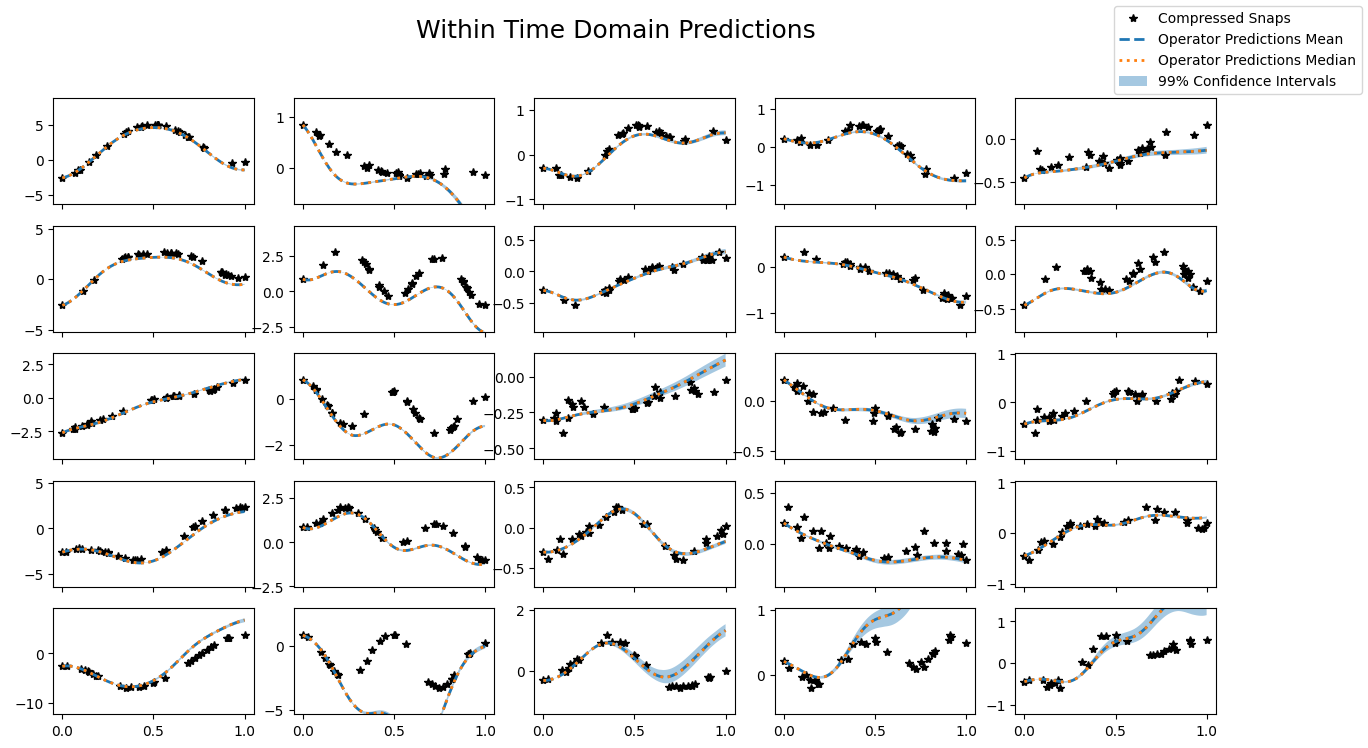

In [ ]:
fig, ax = plt.subplots(numPODmodes, snapshots_compressed.shape[1], figsize=(15,8), sharex=True)
for i in range(len(ax[0])):
    for j in range(len(ax[1])):
        ax[i][j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='Compressed Snaps')
        ax[i][j].plot(eval_time, mean_sample[i,j], label='Operator Predictions Mean', lw=2, linestyle='--')
        ax[i][j].plot(eval_time, median_sample[i,j], label='Operator Predictions Median', lw=2, linestyle=':')
        ax[i][j].fill_between(eval_time, q5[i,j], q95[i,j], alpha=.4, label='99% Confidence Intervals')
        # ax[i][j].plot(eval_time, op_trajs[i,j], label='GP-Bayes Predictions', lw=2)
        data = snapshots_compressed[i, j]
        mn, mx = data.min(), data.max()
        dy = (mx - mn) * 0.5    # 50% padding
        ax[i, j].set_ylim(mn - dy, mx + dy)

handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels)
fig.suptitle('Within Time Domain Predictions', fontsize=18)
# fig.tight_layout()

##### Trajectory Comparison Outside of training Domain

In [ ]:
eval_time = config.time_domain

import random
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

num_pod_modes = snapshots_compressed.shape[0]
pred_samples = []
op_trajs = []

for j in range(ndraws):
    trajs = []
    for i in range(num_pod_modes):
        # keep drawing until the solver produces exactly len(eval_time) time‐points
        num_retrys = 0
        while True:
            num_retrys += 1
            if num_retrys == 1000:
                raise RuntimeError
            idx = random.randint(0, len(samples['O']) - 1)
            O_sample = samples['O'][idx]

            # re‐load the operator into your ROM
            rom._extract_operators(np.array(O_sample))

            # predict gives you `predict_result_.t` and `.y`
            rom.predict(
                state0=snapshots_compressed[i, :, 0],
                t=eval_time,
                input_func=config.input_func_factory(config.input_parameters[i])
            )
            sol = rom.predict_result_

            if sol.t.shape[0] != eval_time.shape[0]:
                print(f"Mode {i}: got {sol.t.shape[0]} time‐steps, expected {eval_time.shape[0]}. Retrying…")
                continue

            # success: store the trajectory (shape: [state_dim, len(eval_time)]) and break out
            trajs.append(sol.y)
            break

    pred_samples.append(trajs)

for i in range(numPODmodes):
    rom._extract_operators(place_holder_O)
    rom.predict(
        state0=snapshots_compressed[i, :, 0],
        t=eval_time,
        input_func=config.input_func_factory(config.input_parameters[i])
    )
    sol = rom.predict_result_
    op_trajs.append(sol.y)

pred_samples = np.array(pred_samples)
op_trajs = np.array(op_trajs)

In [ ]:
mean_sample = pred_samples.mean(axis=0)
median_sample = np.median(pred_samples, axis=0)
q5 = np.quantile(pred_samples, .01, axis=0)
q95 = np.quantile(pred_samples, .99, axis=0)

pred_samples.shape, op_trajs.shape, mean_sample.shape, median_sample.shape, q5.shape

((250, 5, 5, 500), (5, 5, 500), (5, 5, 500), (5, 5, 500), (5, 5, 500))

Text(0.5, 0.98, 'Outside of Training Predictions')

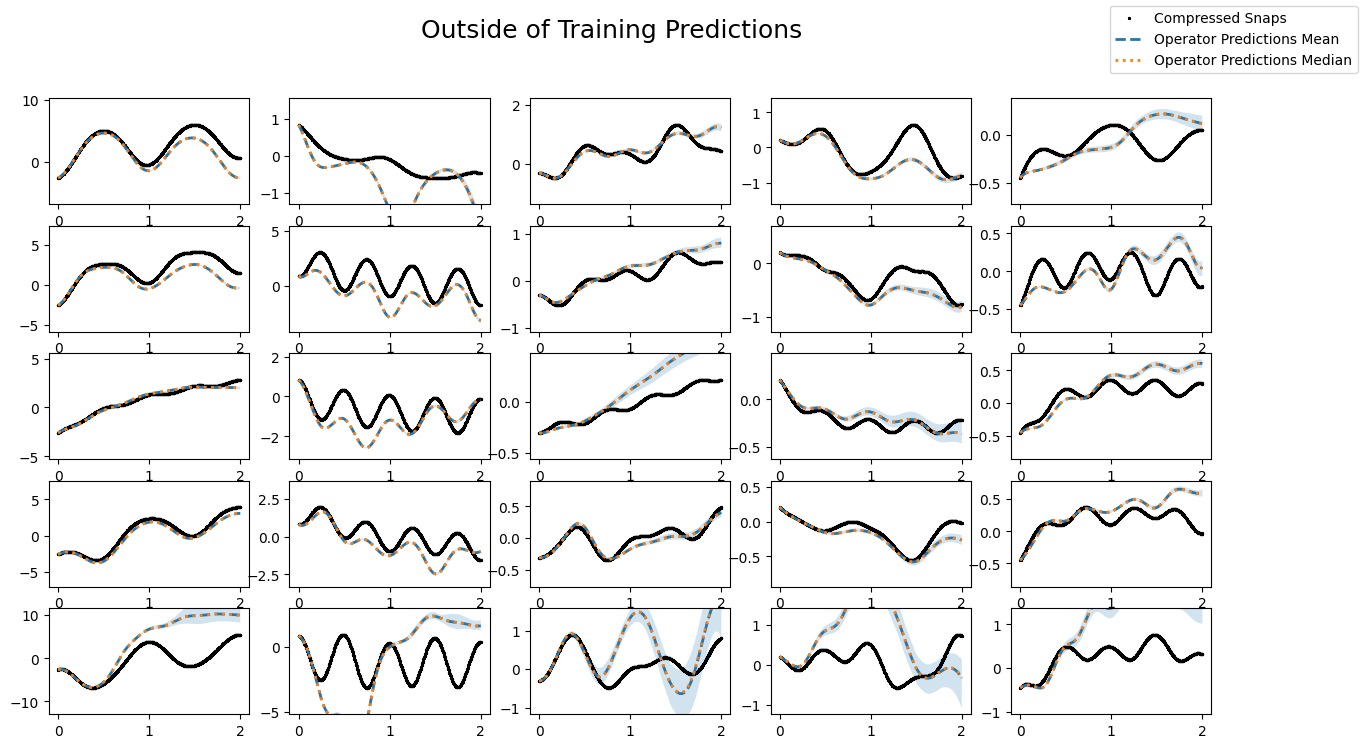

In [ ]:
fig, ax = plt.subplots(numPODmodes, snapshots_compressed.shape[1], figsize=(15,8))
for i in range(len(ax[0])):
    for j in range(len(ax[1])):
        ax[i][j].plot(eval_time, true_states_compressed[i,j], 'k*', label='Compressed Snaps', markersize=2)
        ax[i][j].plot(eval_time, mean_sample[i,j], label='Operator Predictions Mean', lw=2, linestyle='--')
        ax[i][j].plot(eval_time, median_sample[i,j], label='Operator Predictions Median', lw=2, linestyle=':')
        ax[i][j].fill_between(eval_time, q5[i,j], q95[i,j], alpha=.2)
        # ax[i][j].plot(eval_time, op_trajs[i,j], label='GP-Bayes Predictions', lw=2)
        data = true_states_compressed[i, j]
        mn, mx = data.min(), data.max()
        dy = (mx - mn) * 0.5    # 50% padding
        ax[i, j].set_ylim(mn - dy, mx + dy)

handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels)
fig.suptitle('Outside of Training Predictions', fontsize=18)